# WELCOME TO BAYMAX

## ALL THE IMPORTANT DEPENDENCIES

In [1]:
import csv
import random
import pandas as pd
import os
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import numpy as np
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,mean_squared_error,r2_score,classification_report,confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
import tabulate
from tensorflow.keras.layers import Dense, Dropout

I0000 00:00:1778397917.705307    5252 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778397917.730467    5252 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778397920.146486    5252 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778397934.369444    5252 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

## Description of Models </br>

### First Module <b>Diagnosis Module</b> :

It employs Artificial Neural Network (ANN) that uses symptoms and their corresponding diagnosed disease provided in 'Training.csv'. It then learns the patterns among different symptoms and uses the learned weights to predict the disease based upon the symptoms provided by user. 

* It has 3 feed forward layers
* It employs 2 dropout layers with certain probabilities to prevent overfitting
* The module also exhibits graphs for learning curves to exhibit the progress of ANN

### Second Module <b>Severity Prediction</b> :

It employs a Linear Regression Model (LR). The severity column is calculated prior to training </br> 
given by the formula : <b>Summation(weight_of_found_symptoms)*Disease_severity</b></br>
Severity of disease prepared based on expert's opinion</br>
It uses dataset 'Symptom-Severity.csv'

* LR learns weight of each feature from the given dataset 
* It then uses these weights to predict severity of module 
* Boxplot is then used to display the dispersion of severity values 
* A polar Bar graph has been used to visualize importance of each feature in severity calculation 

### Third Module <b>Prescription For the Patient</b>:

It will employ a Genetic Algorithm that will combine Datasets of 'description.csv','diets.csv','medications.csv','precautions_df.csv' and 'workout_df.csv' as genes of chromosomes and then suggest to a patient best combination of all these perscriptions. 

## Description of Dataset

The dataset for model training has been downloaded from Kaggle</br>
Source link :  </br>
</br>
This dataset records a multitude (132) sympotms seen in patients and also maps them to the diseases that were identified for occurrence of certain pattern of symptoms.</br>
Moreover this dataset provides us with the following information :</br> 
+ Maps Symptoms -> Diseases
+ Maps Diseases -> Medication
+ Maps Diseases -> Workout Suggested
+ Maps Diseases -> Precautionary Habbits suggested to be adopted
+ Maps Diseases -> Diet suggested 
+ Maps Diseases -> Disease's description in detail for user's comprehensibility


### LOADING DATASETS

In [62]:
file_path = []
file_path.append(os.path.join('Data','gem','description.csv'))
file_path.append(os.path.join('Data','gem','diets.csv'))
file_path.append(os.path.join('Data','gem','medications.csv'))
file_path.append(os.path.join('Data','gem','precautions_df.csv'))
file_path.append(os.path.join('Data','gem','workout_df.csv'))
file_path.append(os.path.join('Data','gem','Training.csv'))
file_path.append(os.path.join('Data','gem','symtoms_df.csv'))
file_path.append(os.path.join('Data','gem','Symptom-severity.csv'))
DATASET = []

for i in file_path:
    with open(i,mode = 'r') as file:
        data = pd.read_csv(file)
        DATASET.append(data)



In [63]:


unique = DATASET[5].drop_duplicates().copy()
duplicated = DATASET[5][DATASET[5].duplicated()].copy()


def mutate(duplicated):
    mutation_rate = 0.02
    columns = duplicated.columns[:-1] # removing prognosis
    
    for i in range(len(duplicated)):
        
        for j in range(len(columns)):
            
            if random.random() < mutation_rate:
                
                duplicated.iat[i ,j] = 1 - duplicated.iat[i ,j]
                
    return duplicated


mutated_df = mutate(duplicated)

print("After mutation duplicates:", mutated_df.duplicated().sum())
    
final_dataset = pd.concat([unique, mutated_df], ignore_index=True)
DATASET[5] = final_dataset
print("final dataset len:", len(final_dataset))
print("final dataset duplicates:", final_dataset.duplicated().sum())


After mutation duplicates: 252
final dataset len: 4920
final dataset duplicates: 404


## Meta-Data

In [5]:
for i in range(len(DATASET)):
    print(f"\033[91mDataset {i+1}:\033[0m")
    print(DATASET[i].info())
    print(f'Shape of dataset : {DATASET[i].shape}')
    print(f'Number of rows: {len(DATASET[i])}')
    print(f'Number of columns: {len(DATASET[i].columns)}')
    print(f'Number of Nulls : {DATASET[i].isnull().sum().sum()}')
    print("\033[91m===========================================\033[0m\n")

Dataset 1:
<class 'pandas.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Disease      41 non-null     str  
 1   Description  41 non-null     str  
dtypes: str(2)
memory usage: 788.0 bytes
None
Shape of dataset : (41, 2)
Number of rows: 41
Number of columns: 2
Number of Nulls : 0

Dataset 2:
<class 'pandas.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Disease  41 non-null     str  
 1   Diet     41 non-null     str  
dtypes: str(2)
memory usage: 788.0 bytes
None
Shape of dataset : (41, 2)
Number of rows: 41
Number of columns: 2
Number of Nulls : 0

Dataset 3:
<class 'pandas.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Disease     41 non-null     str  
 1   

## Pre Processing

In [64]:
DATASET[5].drop('fluid_overload.1',axis =1,inplace = True)
print('fluid_overload.1' in DATASET[5].columns)


False


In [65]:
# encoding label part 
# using label encoding 
le = LabelEncoder()
DATASET[5]['prognosis'] = le.fit_transform(DATASET[5]['prognosis'])
print(DATASET[5]['prognosis'])

0       15
1       15
2       15
3       15
4       15
        ..
4915     0
4916     2
4917    38
4918    35
4919    27
Name: prognosis, Length: 4920, dtype: int64


In [66]:
for i in range(len(DATASET)):
    DATASET[i].columns = DATASET[i].columns.str.strip()
    DATASET[i] = DATASET[i].apply(lambda col: col.str.strip() if col.dtype == 'object' else col)


## Visualizations

In [67]:
# Most common symptoms:

symptom_cols = list(DATASET[5].columns[:-1])
symptom_freq = DATASET[5][symptom_cols].sum()
print(symptom_freq)
symptom_freq = symptom_freq.sort_values(ascending=False)

fig = px.bar(x=symptom_cols[:26],y=symptom_freq[:26],labels={'x':'Symptoms','y':'Frequency'},title='Frequency of Symptoms in Training Dataset',color =symptom_cols[:26])
fig.show()

itching                 719
skin_rash               839
nodal_skin_eruptions    195
continuous_sneezing     296
shivering               188
                       ... 
small_dents_in_nails    185
inflammatory_nails      210
blister                 207
red_sore_around_nose    181
yellow_crust_ooze       204
Length: 131, dtype: int64


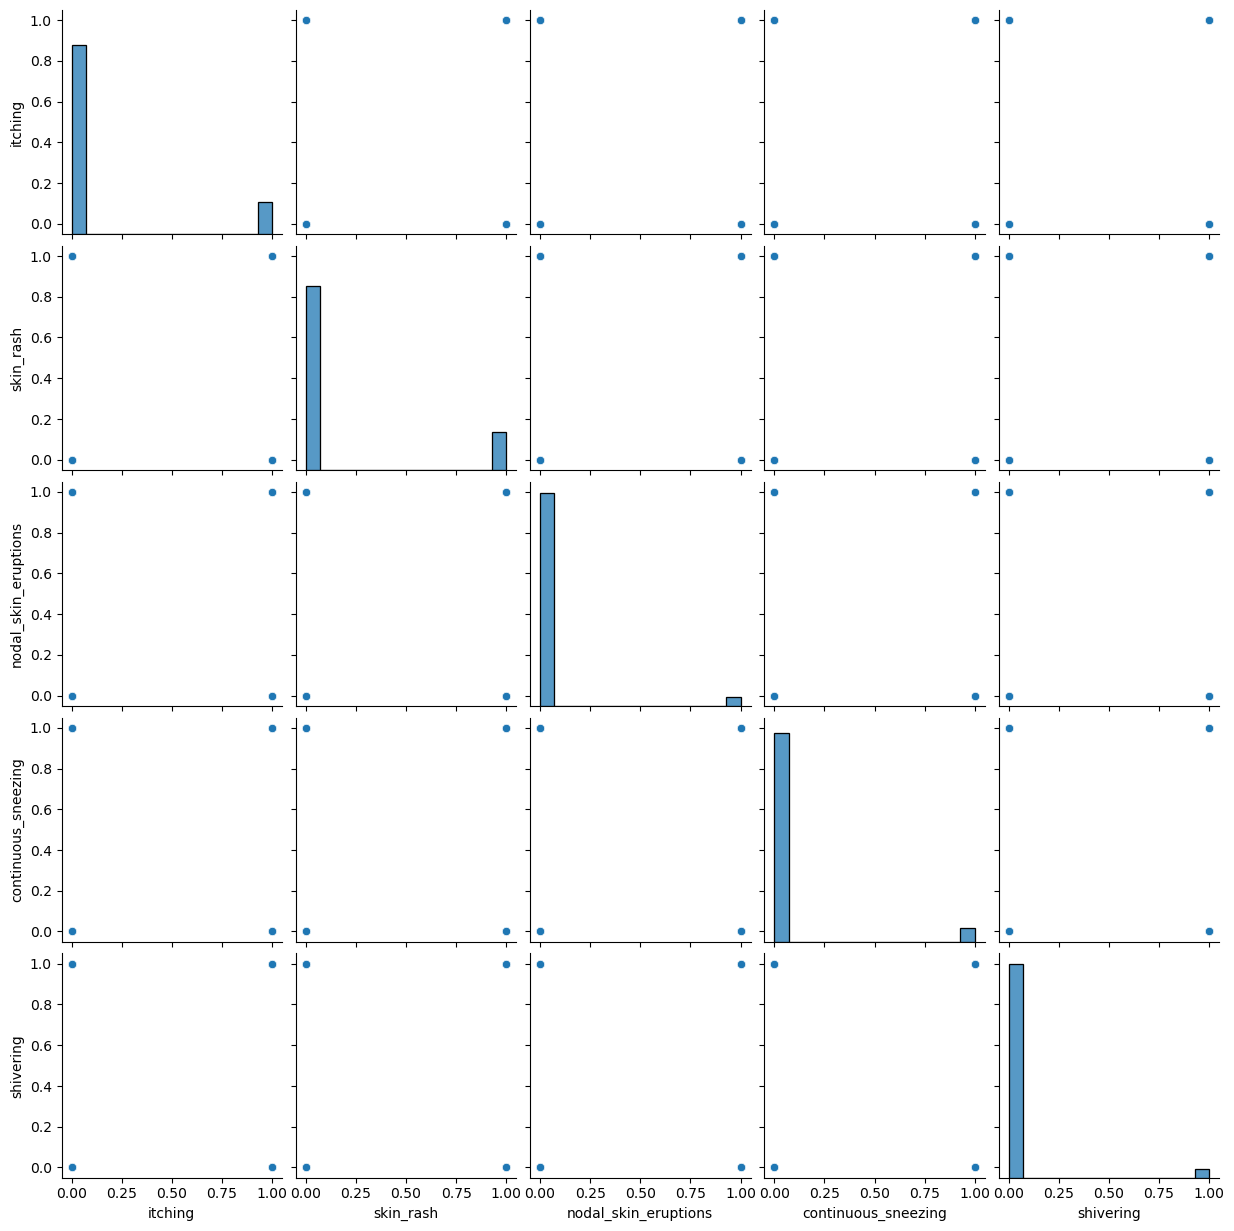

In [68]:
# pair plot between features
# limited to certain features to reduce process time of pairplot (its time complexity is N^2 which can take atleast 20 minutes for our dataset)
sns.pairplot(DATASET[5],vars=DATASET[5].columns[:5])
plt.show()

<AxesSubplot: >

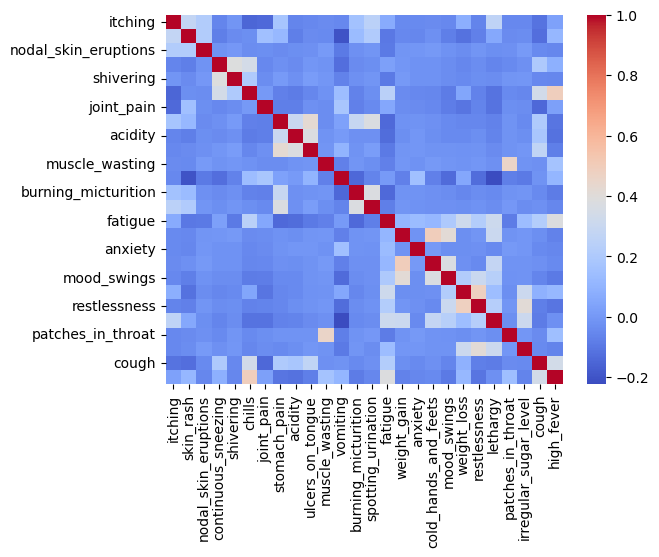

In [69]:
# Correlation between symptoms (which symptoms appear together)
# picking the top 26 symptoms for clarity of heatmap
corr = DATASET[5][symptom_cols[:26]].corr()
sns.heatmap(corr,cmap = 'coolwarm')

## Expert-View On Disease Severity

In [70]:
Disease_severity = {
    'Drug Reaction' : 0.52,
    'Malaria' : 0.72,
    'Allergy' : 0.20,
    'Hypothyroidism' : 0.45, 
    'Psoriasis' : 0.18, 
    'GERD' : 0.35, 
    'Chronic cholestasis' : 0.63, 
    'hepatitis A' : 0.65, 
    'Osteoarthristis' : 0.35, 
    '(vertigo) Paroymsal  Positional Vertigo' : 0.28, 
    'Hypoglycemia' : 0.58, 
    'Acne' : 0.05, 
    'Diabetes' : 0.60, 
    'Impetigo' : 0.15, 
    'Hypertension' : 0.48, 
    'Peptic ulcer diseae' : 0.48, 
    'Dimorphic hemmorhoids(piles)' : 0.42, 
    'Common Cold' : 0.08, 
    'Chicken pox' : 0.25, 
    'Cervical spondylosis' : 0.38, 
    'Hyperthyroidism' : 0.50, 
    'Urinary tract infection' : 0.38, 
    'Varicose veins' : 0.32, 
    'AIDS' : 0.90, 
    'Paralysis (brain hemorrhage)' : 0.95, 
    'Typhoid' : 0.65, 
    'Hepatitis B' : 0.78, 
    'Fungal infection' : 0.12, 
    'Hepatitis C' : 0.30, 
    'Migraine' : 0.55, 
    'Bronchial Asthma' : 0.80, 
    'Alcoholic hepatitis' : 0.90, 
    'Jaundice' : 0.60, 
    'Hepatitis E' : 0.70, 
    'Dengue' : 0.68, 
    'Hepatitis D' : 0.76, 
    'Heart attack' : 1.00, 
    'Pneumonia' : 0.63, 
    'Arthritis' : 0.40, 
    'Gastroenteritis' : 0.40,
    'Tuberculosis': 0.82
}

## Calculating Severity for each row in our Dataset

In [71]:
# preparing dataframe for linear regression:
y = []
disease_col = DATASET[5]['prognosis'].copy()
for index,row in DATASET[5].iterrows():
    total = 0
    for col in DATASET[5].columns[:-1]:
        if row[col] == 1:
            total += DATASET[7][DATASET[7]['Symptom'] == col]['weight'].values[0]

    disease_diagnosed = le.inverse_transform([row[DATASET[5].columns[-1]]])
    total = total*Disease_severity[disease_diagnosed[0]]
    y.append(total)

## Severity Box-Plot

Mean : 21.22	Min : 0.3	Max : 82.0
Standard Deviation : 14.42	Range : 81.7



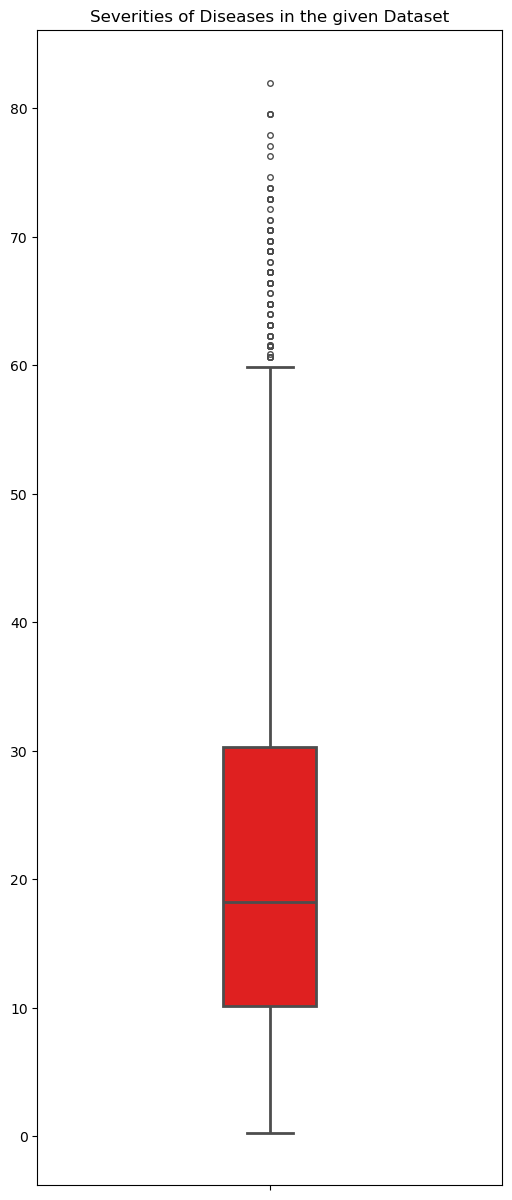

In [74]:
result = np.array(y)
print(f'Mean : {round(result.mean(),2)}\tMin : {round(result.min(),2)}\tMax : {round(result.max(),2)}\nStandard Deviation : {round(result.std(),2)}\tRange : {round(result.max(),2)-round(result.min(),2)}\n')
plt.figure(figsize=(6,15))
sns.boxplot(y=y,width = 0.2,color= "red",linewidth= 2,fliersize=4)
plt.title("Severities of Diseases in the given Dataset")
plt.show()

## LINEAR REGRESSION (SEVERITY MODULE)

In [75]:
# splitting data first for test and train

X = DATASET[5]
y = y.copy()

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LinearRegression()

model.fit(X_train,y_train)

pred_y = model.predict(X_test)

print(f'\033[91mmean_squared_error : {mean_squared_error(y_test,pred_y)}\033[0m')
print(f'\033[92mR^2 score : {r2_score(y_test,pred_y)}\033[0m')

mean_squared_error : 18.655751954587675
R^2 score : 0.9136196678444992


In [78]:
weights = pd.Series(model.coef_,index=DATASET[5].columns)
weights.sort_values(ascending=False)
px.bar(x=weights[:],title='Importance of Each weight in Calbculating Severity',color = DATASET[5].columns[:])

In [89]:
def Predict_Severity_of_Disease(Symptoms):
    pred_y = model.predict(Symptoms)
    status = ''
    if pred_y > result.mean()+10:
        status = '\033[91mHIGH\033[0m'
    elif pred_y < result.mean():
        status = '\033[92mLow\033[0m'
    else:
        status = '\033[93mMedium\033[0m'
    return (pred_y[0],status)

In [90]:
#testing LR
x,y = Predict_Severity_of_Disease(get_symptoms(['itching','chills','vomiting']))
print(f'severity = {x} ==> {y}')

severity = 25.178510050101316 ==> Medium


## ARTIFICAL NEURAL NETWORK (DIAGNOSIS MODULE)

In [163]:
X = final_dataset.drop(columns=['prognosis'])
print(X.columns)

Y = final_dataset['prognosis']
encoder = LabelEncoder()
Y = encoder.fit_transform(Y)


X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=42,stratify=Y)

print(f"\nX_train shape: {X_train.shape} (Training on {X_train.shape[0]} patients, {X_train.shape[1]} symptoms each)")
print(f"y_train shape: {Y_train.shape}")
print(f"X_test shape: {X_test.shape} (test set of {X_test.shape[0]} patients)")
print(f"y_test shape: {Y_train.shape}")

Index(['itching', 'skin_rash', 'nodal_skin_eruptions', 'continuous_sneezing',
       'shivering', 'chills', 'joint_pain', 'stomach_pain', 'acidity',
       'ulcers_on_tongue',
       ...
       'pus_filled_pimples', 'blackheads', 'scurring', 'skin_peeling',
       'silver_like_dusting', 'small_dents_in_nails', 'inflammatory_nails',
       'blister', 'red_sore_around_nose', 'yellow_crust_ooze'],
      dtype='str', length=131)

X_train shape: (3936, 131) (Training on 3936 patients, 131 symptoms each)
y_train shape: (3936,)
X_test shape: (984, 131) (test set of 984 patients)
y_test shape: (3936,)


In [95]:
baymax_tf_model = Sequential()

baymax_tf_model.add(Dense(units=64, activation='relu', input_shape=(131,))) # input 131 (symptoms) first hidden layer 64 neurons

baymax_tf_model.add(Dropout(0.2)) # Kill 30% chromosomes for better learning 

baymax_tf_model.add(Dense(units=32, activation='relu')) #second hidden layer with 32 neurons

baymax_tf_model.add(Dropout(0.4))

baymax_tf_model.add(Dense(units=41, activation='softmax')) # output layer with softmax acitvation

baymax_tf_model.summary()

baymax_tf_model.compile(
    optimizer='adam', 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

history = baymax_tf_model.fit(
    X_train, 
    Y_train,
    epochs=50,            
    batch_size=32,        
    validation_data=(X_test,Y_test), 
    verbose=1             
)




/home/crazymonkey/.local/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 64)             │         8,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 41)             │         1,353 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,881 (46.41 KB)

 Trainable params: 11,881 (46.41 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.1471 - loss: 3.3541 - val_accuracy: 0.6463 - val_loss: 2.6493
Epoch 2/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.4957 - loss: 2.1170 - val_accuracy: 0.9482 - val_loss: 1.0367
Epoch 3/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.6969 - loss: 1.2249 - val_accuracy: 0.9929 - val_loss: 0.4105
Epoch 4/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.7790 - loss: 0.8348 - val_accuracy: 0.9990 - val_loss: 0.1995
Epoch 5/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.8323 - loss: 0.6477 - val_accuracy: 0.9980 - val_loss: 0.1150
Epoch 6/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.8498 - loss: 0.5353 - val_accuracy: 0.9980 - val_loss: 0.0744
Epoch 7/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.8659 - loss: 0.4814 - val_accuracy: 0.9980 - val_loss: 0.0549
Epoch 8/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.8679 - loss: 0.4288 - val_accu

In [ ]:
def RunDiagnosis(Symptoms):
    probabilities = baymax_tf_model.predict(Symptoms,verbose=0)[0]
    top_probs = np.argsort(probabilities)[::-1][:3]
    top_disease_names = encoder.inverse_transform(top_probs)
    top3_diseases_confidentiality_score = probabilities[top_probs]
    return top_disease_names,top3_diseases_confidentiality_score



## visualizing the ann 

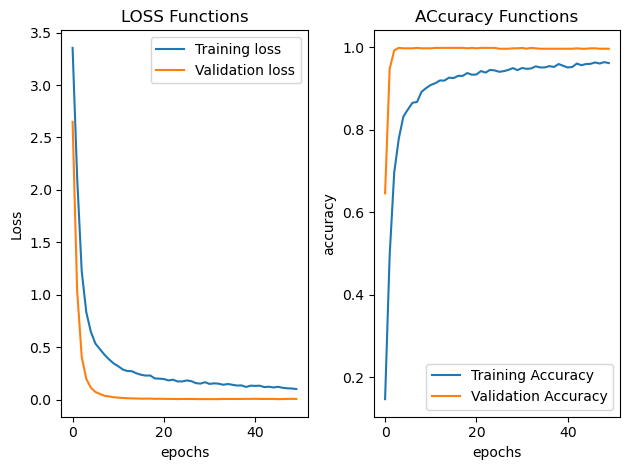

In [97]:


train_loss = history.history['loss']
val_loss = history.history['val_loss']
val_acc = history.history['val_accuracy']
train_acc = history.history['accuracy']

plt.subplot(1,2,1)
plt.plot(train_loss,label='Training loss')
plt.plot(val_loss,label='Validation loss')
plt.title("LOSS Functions")
plt.xlabel('epochs')
plt.ylabel('Loss')
plt.legend()


plt.subplot(1,2,2)
plt.plot(train_acc,label='Training Accuracy')
plt.plot(val_acc,label='Validation Accuracy')
plt.title("ACcuracy Functions")
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.legend()
plt.tight_layout(


)
plt.show()




In [98]:
Y_pred_probs = baymax_tf_model.predict(X_test, verbose=0)
Y_pred       = np.argmax(Y_pred_probs, axis=1)
Y_pred_names = encoder.inverse_transform(Y_pred)
Y_true_names = encoder.inverse_transform(Y_test)
print(f'Accuracy Score of Our Baymax is : {round(accuracy_score(Y_pred_names,Y_true_names)*100,2)}%')
print(f'classification report: \n {classification_report(Y_true_names,Y_pred_names)}')
print(f'CONFUSION MATRIX__________________________________\n{confusion_matrix(Y_true_names,Y_pred_names)}')

Accuracy Score of Our Baymax is : 99.7%
classification report: 
               precision    recall  f1-score   support

           0       0.96      1.00      0.98        24
           1       1.00      1.00      1.00        24
           2       1.00      1.00      1.00        24
           3       1.00      1.00      1.00        24
           4       1.00      1.00      1.00        24
           5       1.00      1.00      1.00        24
           6       1.00      1.00      1.00        24
           7       1.00      1.00      1.00        24
           8       1.00      1.00      1.00        24
           9       1.00      0.96      0.98        24
          10       1.00      1.00      1.00        24
          11       1.00      1.00      1.00        24
          12       1.00      1.00      1.00        24
          13       1.00      1.00      1.00        24
          14       1.00      1.00      1.00        24
          15       1.00      1.00      1.00        24
          16    

## MODELS INTEGRATION 

In [169]:
def get_symptoms(Symptoms):
    ALL_SYMPTOMS = DATASET[5].columns
    v = np.zeros(len(ALL_SYMPTOMS))
    
    for i in Symptoms:
        i = i.strip().lower().replace(' ','_')
        found = False

        for j in range(len(ALL_SYMPTOMS)):
             if ALL_SYMPTOMS[j].lower() == i:
                 v[j] = 1
                 found = True
                 break
        
        if not found:
            print(f"\033[91mSymptom {i} is skipped because it wasnt found\033[0m")

    v = v.reshape(1,-1)
    return v

def baymax(something):
    print()
    symps = get_symptoms(something)
    diseases,confidentiality_scores = RunDiagnosis(symps[:,:-1])
    data = list(zip(diseases,confidentiality_scores*100))
    print(f'Diseases Predicted by ANN along with their confidentiality scores are:')
    print(tabulate.tabulate(data,headers=['Diseases','Chances'],tablefmt='rounded_outline',floatfmt='.2f'))

    severity,status = Predict_Severity_of_Disease(symps)
    print(f'\nSeverity Predicted by our Linear Regression Model : {round(float(severity),2)} ====> {status}')


## TESTING THE MODEL

In [170]:
baymax(['itching','redness_of_eyes','blood_in_sputum'])


Diseases Predicted by ANN along with their confidentiality scores are:
╭────────────┬───────────╮
│   Diseases │   Chances │
├────────────┼───────────┤
│         14 │     71.51 │
│         15 │     19.57 │
│         39 │      2.19 │
╰────────────┴───────────╯

Severity Predicted by our Linear Regression Model : 22.01 ====> Medium


In [146]:
baymax(['itching'])


Diseases Predicted by ANN along with their confidentiality scores are:
╭────────────┬───────────╮
│   Diseases │   Chances │
├────────────┼───────────┤
│         15 │     92.85 │
│         14 │      4.26 │
│          9 │      1.57 │
╰────────────┴───────────╯

Severity Predicted by our Linear Regression Model : 20.68 ====> Low


In [147]:
#_______FINDING WORST CASE FROM OUR DATASET______________
cooked = DATASET[5].iloc[np.argmax(result)].values[:-1]
symps = []
cols = DATASET[5].columns
for i in range(len(cooked)):
    for col in cols:
        if cols[i] == col:
            symps.append(col)

baymax(symps)


Diseases Predicted by ANN along with their confidentiality scores are:
╭────────────┬───────────╮
│   Diseases │   Chances │
├────────────┼───────────┤
│         35 │     61.55 │
│          4 │     19.10 │
│         27 │     15.56 │
╰────────────┴───────────╯

Severity Predicted by our Linear Regression Model : 92.2 ====> HIGH


In [148]:
baymax(['cough','itching','headache'])

Diseases Predicted by ANN along with their confidentiality scores are:
╭────────────┬───────────╮
│   Diseases │   Chances │
├────────────┼───────────┤
│          8 │     41.25 │
│         14 │     23.39 │
│         15 │     20.58 │
╰────────────┴───────────╯

Severity Predicted by our Linear Regression Model : 22.11 ====> Medium
